# Brain Tumor Dataset Analysis

Comprehensive analysis of the LGG Segmentation Dataset to understand:
- Class imbalance (tumor vs non-tumor pixels)
- Empty masks (slices with no tumor)
- Tumor size distribution
- Image quality metrics
- Patient-level statistics

## Dataset Information
- **Source**: TCGA Lower Grade Glioma (LGG) collection
- **Modalities**: T1 pre-contrast, FLAIR, T1 post-contrast
- **Task**: Binary segmentation of FLAIR abnormality

## 1. Import Libraries

In [3]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from PIL import Image
from collections import defaultdict

import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset Paths

In [4]:
# Set data paths
DATA_DIR = Path('archive/kaggle_3m')
print(f"Dataset directory: {DATA_DIR}")
print(f"Directory exists: {DATA_DIR.exists()}\n")

if not DATA_DIR.exists():
    print("⚠️  Dataset directory not found!")
    print("Please update DATA_DIR to point to your LGG dataset location.")
else:
    # Get all patient folders
    patient_folders = sorted([f for f in DATA_DIR.iterdir() if f.is_dir() and f.name.startswith('TCGA')])
    print(f"✓ Found {len(patient_folders)} patients")
    
    # Collect all image and mask paths
    image_paths = []
    mask_paths = []
    patient_ids = []
    
    for patient_folder in patient_folders:
        images = sorted([f for f in patient_folder.glob('*.tif') if '_mask' not in f.name])
        masks = sorted([f for f in patient_folder.glob('*_mask.tif')])
        
        image_paths.extend(images)
        mask_paths.extend(masks)
        patient_ids.extend([patient_folder.name] * len(images))
    
    print(f"✓ Total images: {len(image_paths):,}")
    print(f"✓ Total masks: {len(mask_paths):,}")
    print(f"\n{'='*70}")

Dataset directory: archive/kaggle_3m
Directory exists: True

✓ Found 110 patients
✓ Total images: 3,929
✓ Total masks: 3,929



## 3. Patient-Level Statistics

PATIENT-LEVEL STATISTICS
Number of patients: 110

Slices per patient:
  Min: 20
  Max: 88
  Mean: 35.7
  Median: 33.0
  Std: 15.1


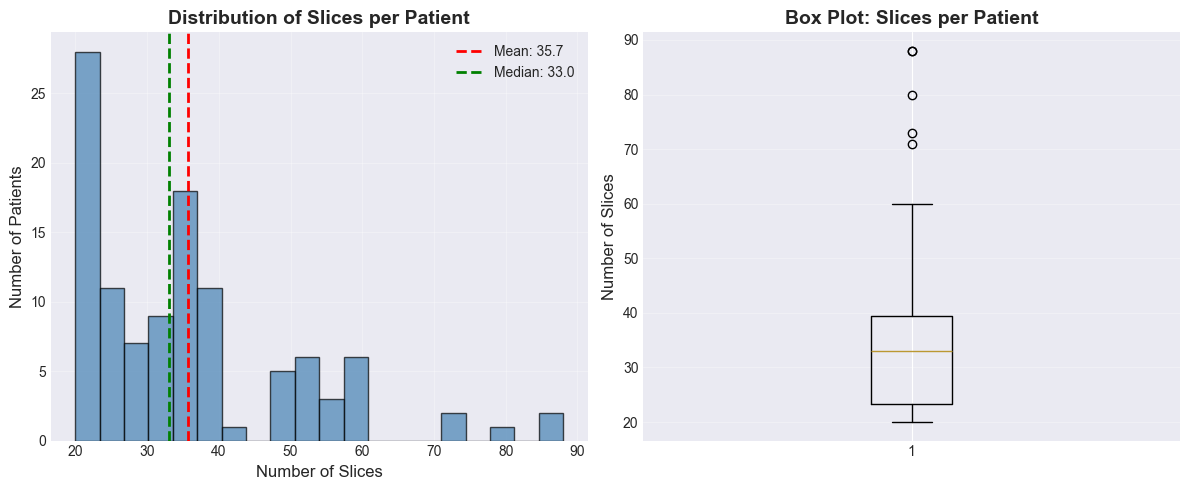

In [5]:
# Count slices per patient
patient_slice_counts = defaultdict(int)
for patient_id in patient_ids:
    patient_slice_counts[patient_id] += 1

slice_counts = list(patient_slice_counts.values())

print("PATIENT-LEVEL STATISTICS")
print("="*70)
print(f"Number of patients: {len(patient_slice_counts)}")
print(f"\nSlices per patient:")
print(f"  Min: {min(slice_counts)}")
print(f"  Max: {max(slice_counts)}")
print(f"  Mean: {np.mean(slice_counts):.1f}")
print(f"  Median: {np.median(slice_counts):.1f}")
print(f"  Std: {np.std(slice_counts):.1f}")
print("="*70)

# Visualize distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(slice_counts, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(np.mean(slice_counts), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(slice_counts):.1f}')
plt.axvline(np.median(slice_counts), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(slice_counts):.1f}')
plt.xlabel('Number of Slices', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.title('Distribution of Slices per Patient', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(slice_counts, vert=True)
plt.ylabel('Number of Slices', fontsize=12)
plt.title('Box Plot: Slices per Patient', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('patient_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Mask Analysis: Tumor Presence & Size

In [6]:
# Analyze each mask
print("Analyzing masks... This may take a few minutes...\n")

mask_stats = []

for idx, (mask_path, patient_id) in enumerate(tqdm(zip(mask_paths, patient_ids), total=len(mask_paths), desc="Processing masks")):
    # Load mask
    mask = np.array(Image.open(mask_path))
    
    # Calculate statistics
    total_pixels = mask.size
    tumor_pixels = (mask > 0).sum()
    tumor_percentage = (tumor_pixels / total_pixels) * 100
    
    # Categorize tumor size
    if tumor_pixels == 0:
        category = 'Empty'
    elif tumor_pixels < 100:
        category = 'Very Small'
    elif tumor_pixels < 500:
        category = 'Small'
    elif tumor_pixels < 2000:
        category = 'Medium'
    else:
        category = 'Large'
    
    mask_stats.append({
        'patient_id': patient_id,
        'mask_path': str(mask_path),
        'total_pixels': total_pixels,
        'tumor_pixels': tumor_pixels,
        'tumor_percentage': tumor_percentage,
        'category': category,
        'has_tumor': tumor_pixels > 0
    })

# Create DataFrame
df_masks = pd.DataFrame(mask_stats)

print(f"\n✓ Analysis complete!")
print(f"\nDataFrame shape: {df_masks.shape}")
df_masks.head()

Analyzing masks... This may take a few minutes...



Processing masks: 100%|██████████| 3929/3929 [00:03<00:00, 1037.75it/s]


✓ Analysis complete!

DataFrame shape: (3929, 7)


,patient_id,mask_path,total_pixels,tumor_pixels,tumor_percentage,category,has_tumor
0,TCGA_CS_4941_19960909,archive/kaggle_3m/TCGA_CS_4941_19960909/TCGA_C...,65536,0,0.000000,Empty,False
1,TCGA_CS_4941_19960909,archive/kaggle_3m/TCGA_CS_4941_19960909/TCGA_C...,65536,1426,2.175903,Medium,True
2,TCGA_CS_4941_19960909,archive/kaggle_3m/TCGA_CS_4941_19960909/TCGA_C...,65536,2646,4.037476,Large,True
3,TCGA_CS_4941_19960909,archive/kaggle_3m/TCGA_CS_4941_19960909/TCGA_C...,65536,2765,4.219055,Large,True
4,TCGA_CS_4941_19960909,archive/kaggle_3m/TCGA_CS_4941_19960909/TCGA_C...,65536,2877,4.389954,Large,True


## 5. Class Imbalance Analysis

In [7]:
print("\n" + "="*70)
print("CLASS IMBALANCE ANALYSIS")
print("="*70)

# Empty vs non-empty masks
empty_masks = (df_masks['tumor_pixels'] == 0).sum()
non_empty_masks = (df_masks['tumor_pixels'] > 0).sum()

print(f"\nMask Distribution:")
print(f"  Empty masks (no tumor): {empty_masks:,} ({empty_masks/len(df_masks)*100:.1f}%)")
print(f"  Non-empty masks (with tumor): {non_empty_masks:,} ({non_empty_masks/len(df_masks)*100:.1f}%)")

# Tumor size categories
print(f"\nTumor Size Categories:")
category_counts = df_masks['category'].value_counts()
for category, count in category_counts.items():
    print(f"  {category:12s}: {count:,} ({count/len(df_masks)*100:.1f}%)")

# Pixel-level class imbalance
total_pixels_all = df_masks['total_pixels'].sum()
tumor_pixels_all = df_masks['tumor_pixels'].sum()
non_tumor_pixels_all = total_pixels_all - tumor_pixels_all

print(f"\nPixel-Level Distribution:")
print(f"  Total pixels: {total_pixels_all:,}")
print(f"  Tumor pixels: {tumor_pixels_all:,} ({tumor_pixels_all/total_pixels_all*100:.2f}%)")
print(f"  Non-tumor pixels: {non_tumor_pixels_all:,} ({non_tumor_pixels_all/total_pixels_all*100:.2f}%)")
print(f"  Imbalance ratio (non-tumor : tumor): {non_tumor_pixels_all/tumor_pixels_all:.1f} : 1")

print("="*70)


CLASS IMBALANCE ANALYSIS

Mask Distribution:
  Empty masks (no tumor): 2,556 (65.1%)
  Non-empty masks (with tumor): 1,373 (34.9%)

Tumor Size Categories:
  Empty       : 2,556 (65.1%)
  Medium      : 594 (15.1%)
  Large       : 540 (13.7%)
  Small       : 208 (5.3%)
  Very Small  : 31 (0.8%)

Pixel-Level Distribution:
  Total pixels: 257,490,944
  Tumor pixels: 2,651,854 (1.03%)
  Non-tumor pixels: 254,839,090 (98.97%)
  Imbalance ratio (non-tumor : tumor): 96.1 : 1


## 6. Tumor Size Distribution Visualization

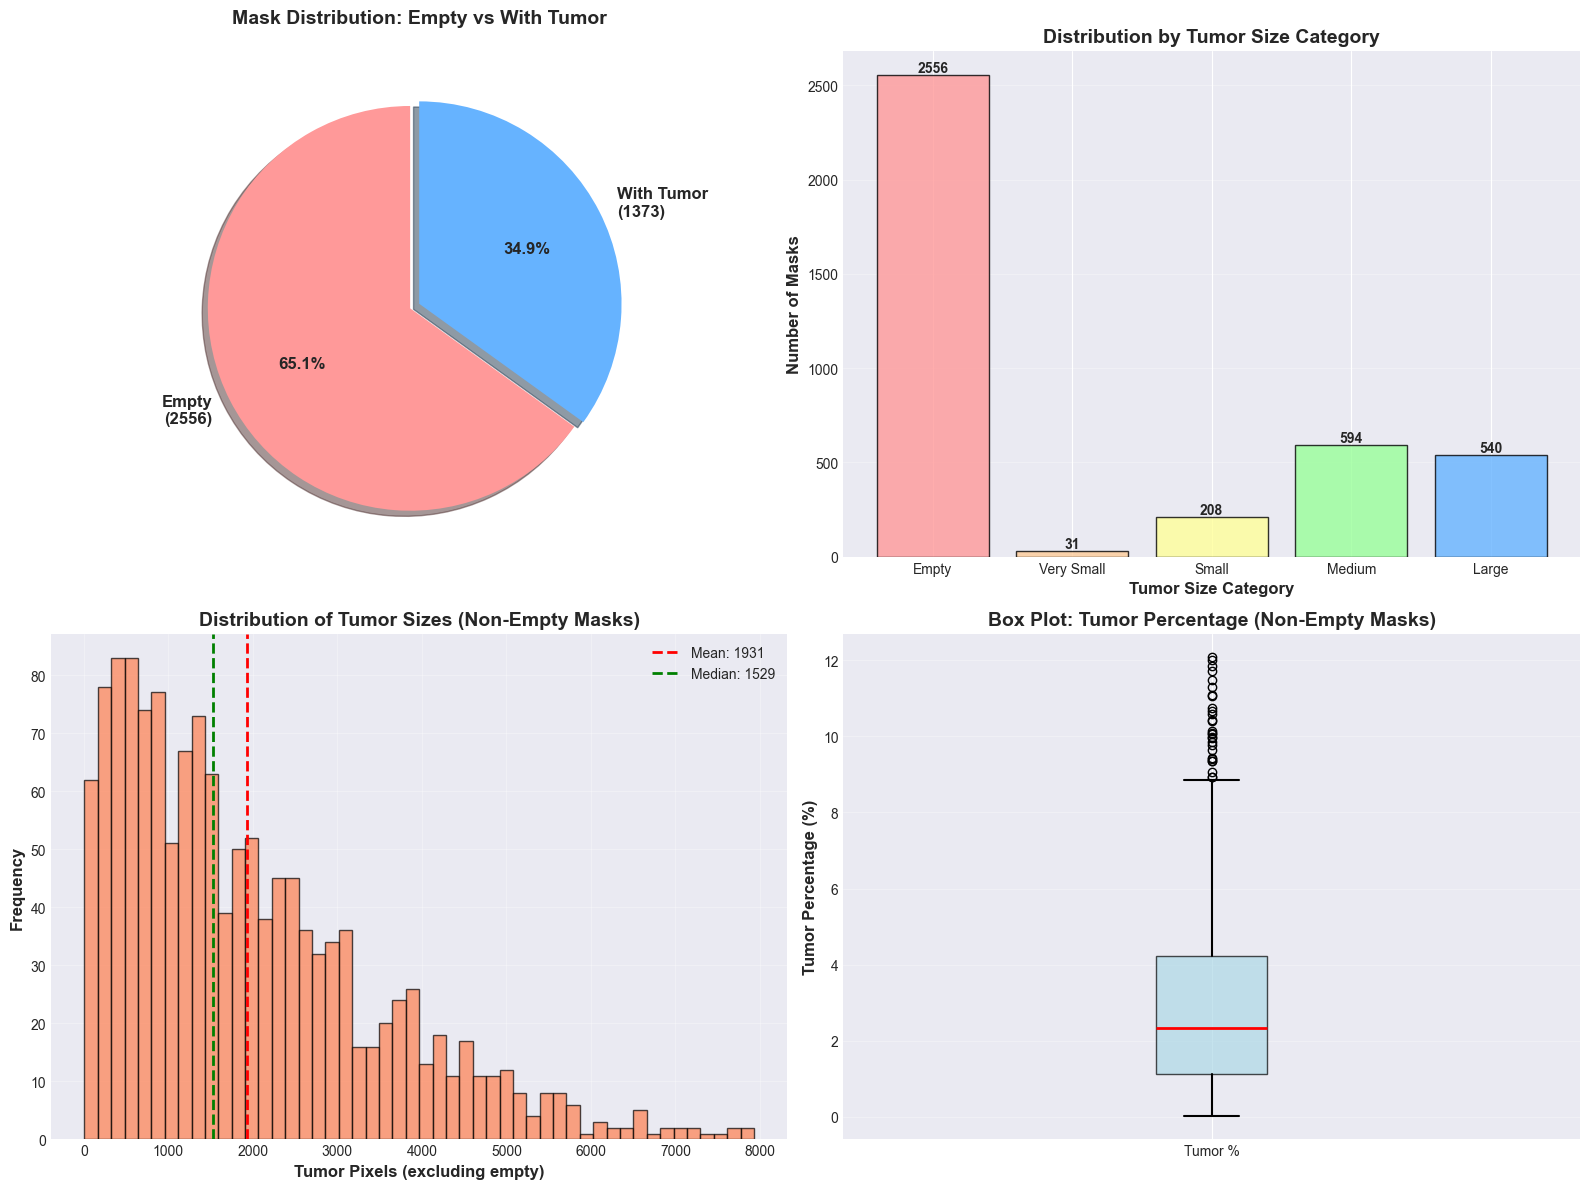

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Pie chart: Empty vs Non-empty
ax1 = axes[0, 0]
sizes = [empty_masks, non_empty_masks]
labels = [f'Empty\n({empty_masks})', f'With Tumor\n({non_empty_masks})']
colors = ['#ff9999', '#66b3ff']
explode = (0.05, 0)
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax1.set_title('Mask Distribution: Empty vs With Tumor', fontsize=14, fontweight='bold', pad=20)

# 2. Bar chart: Tumor size categories
ax2 = axes[0, 1]
category_order = ['Empty', 'Very Small', 'Small', 'Medium', 'Large']
category_counts_ordered = df_masks['category'].value_counts().reindex(category_order, fill_value=0)
bars = ax2.bar(category_counts_ordered.index, category_counts_ordered.values, 
               color=['#ff9999', '#ffcc99', '#ffff99', '#99ff99', '#66b3ff'], edgecolor='black', alpha=0.8)
ax2.set_xlabel('Tumor Size Category', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Masks', fontsize=12, fontweight='bold')
ax2.set_title('Distribution by Tumor Size Category', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold')

# 3. Histogram: Tumor pixel counts (non-empty only)
ax3 = axes[1, 0]
non_empty_data = df_masks[df_masks['tumor_pixels'] > 0]['tumor_pixels']
ax3.hist(non_empty_data, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax3.axvline(non_empty_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {non_empty_data.mean():.0f}')
ax3.axvline(non_empty_data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {non_empty_data.median():.0f}')
ax3.set_xlabel('Tumor Pixels (excluding empty)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax3.set_title('Distribution of Tumor Sizes (Non-Empty Masks)', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Box plot: Tumor percentage distribution
ax4 = axes[1, 1]
non_empty_percentage = df_masks[df_masks['tumor_pixels'] > 0]['tumor_percentage']
bp = ax4.boxplot(non_empty_percentage, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5))
ax4.set_ylabel('Tumor Percentage (%)', fontsize=12, fontweight='bold')
ax4.set_title('Box Plot: Tumor Percentage (Non-Empty Masks)', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_xticklabels(['Tumor %'])

plt.tight_layout()
plt.savefig('tumor_distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Tumor Statistics Summary

In [9]:
# Non-empty masks statistics
non_empty_df = df_masks[df_masks['tumor_pixels'] > 0]

print("\n" + "="*70)
print("TUMOR STATISTICS (NON-EMPTY MASKS ONLY)")
print("="*70)
print(f"\nNumber of masks with tumor: {len(non_empty_df):,}")
print(f"\nTumor Pixel Count:")
print(f"  Min: {non_empty_df['tumor_pixels'].min():.0f}")
print(f"  Max: {non_empty_df['tumor_pixels'].max():.0f}")
print(f"  Mean: {non_empty_df['tumor_pixels'].mean():.0f}")
print(f"  Median: {non_empty_df['tumor_pixels'].median():.0f}")
print(f"  Std: {non_empty_df['tumor_pixels'].std():.0f}")
print(f"\nTumor Percentage:")
print(f"  Min: {non_empty_df['tumor_percentage'].min():.2f}%")
print(f"  Max: {non_empty_df['tumor_percentage'].max():.2f}%")
print(f"  Mean: {non_empty_df['tumor_percentage'].mean():.2f}%")
print(f"  Median: {non_empty_df['tumor_percentage'].median():.2f}%")
print(f"  Std: {non_empty_df['tumor_percentage'].std():.2f}%")
print("="*70)


TUMOR STATISTICS (NON-EMPTY MASKS ONLY)

Number of masks with tumor: 1,373

Tumor Pixel Count:
  Min: 7
  Max: 7929
  Mean: 1931
  Median: 1529
  Std: 1530

Tumor Percentage:
  Min: 0.01%
  Max: 12.10%
  Mean: 2.95%
  Median: 2.33%
  Std: 2.33%


## 8. Patient-Level Tumor Analysis


PATIENT-LEVEL TUMOR ANALYSIS

Slices with tumor per patient:
  Min: 3
  Max: 37
  Mean: 12.5
  Median: 11.0

Percentage of slices with tumor per patient:
  Min: 13.5%
  Max: 66.7%
  Mean: 35.6%
  Median: 35.7%


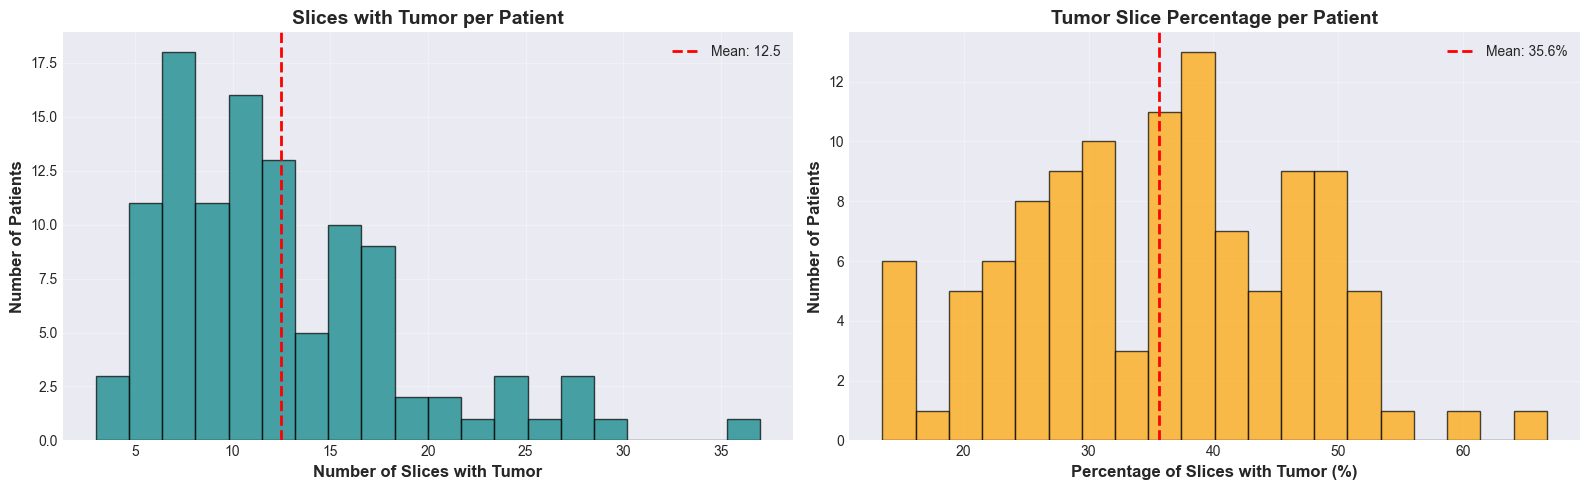

In [10]:
# Group by patient
patient_tumor_stats = df_masks.groupby('patient_id').agg({
    'tumor_pixels': ['sum', 'mean', 'max'],
    'has_tumor': 'sum',  # Number of slices with tumor per patient
    'patient_id': 'count'  # Total slices per patient
}).reset_index()

patient_tumor_stats.columns = ['patient_id', 'total_tumor_pixels', 'mean_tumor_pixels', 
                                 'max_tumor_pixels', 'slices_with_tumor', 'total_slices']

# Calculate percentage of slices with tumor per patient
patient_tumor_stats['tumor_slice_percentage'] = (
    patient_tumor_stats['slices_with_tumor'] / patient_tumor_stats['total_slices'] * 100
)

print("\n" + "="*70)
print("PATIENT-LEVEL TUMOR ANALYSIS")
print("="*70)
print(f"\nSlices with tumor per patient:")
print(f"  Min: {patient_tumor_stats['slices_with_tumor'].min():.0f}")
print(f"  Max: {patient_tumor_stats['slices_with_tumor'].max():.0f}")
print(f"  Mean: {patient_tumor_stats['slices_with_tumor'].mean():.1f}")
print(f"  Median: {patient_tumor_stats['slices_with_tumor'].median():.1f}")
print(f"\nPercentage of slices with tumor per patient:")
print(f"  Min: {patient_tumor_stats['tumor_slice_percentage'].min():.1f}%")
print(f"  Max: {patient_tumor_stats['tumor_slice_percentage'].max():.1f}%")
print(f"  Mean: {patient_tumor_stats['tumor_slice_percentage'].mean():.1f}%")
print(f"  Median: {patient_tumor_stats['tumor_slice_percentage'].median():.1f}%")
print("="*70)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of slices with tumor per patient
axes[0].hist(patient_tumor_stats['slices_with_tumor'], bins=20, edgecolor='black', alpha=0.7, color='teal')
axes[0].axvline(patient_tumor_stats['slices_with_tumor'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {patient_tumor_stats["slices_with_tumor"].mean():.1f}')
axes[0].set_xlabel('Number of Slices with Tumor', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Patients', fontsize=12, fontweight='bold')
axes[0].set_title('Slices with Tumor per Patient', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Percentage of slices with tumor per patient
axes[1].hist(patient_tumor_stats['tumor_slice_percentage'], bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(patient_tumor_stats['tumor_slice_percentage'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {patient_tumor_stats["tumor_slice_percentage"].mean():.1f}%')
axes[1].set_xlabel('Percentage of Slices with Tumor (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Patients', fontsize=12, fontweight='bold')
axes[1].set_title('Tumor Slice Percentage per Patient', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('patient_tumor_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Sample Visualization

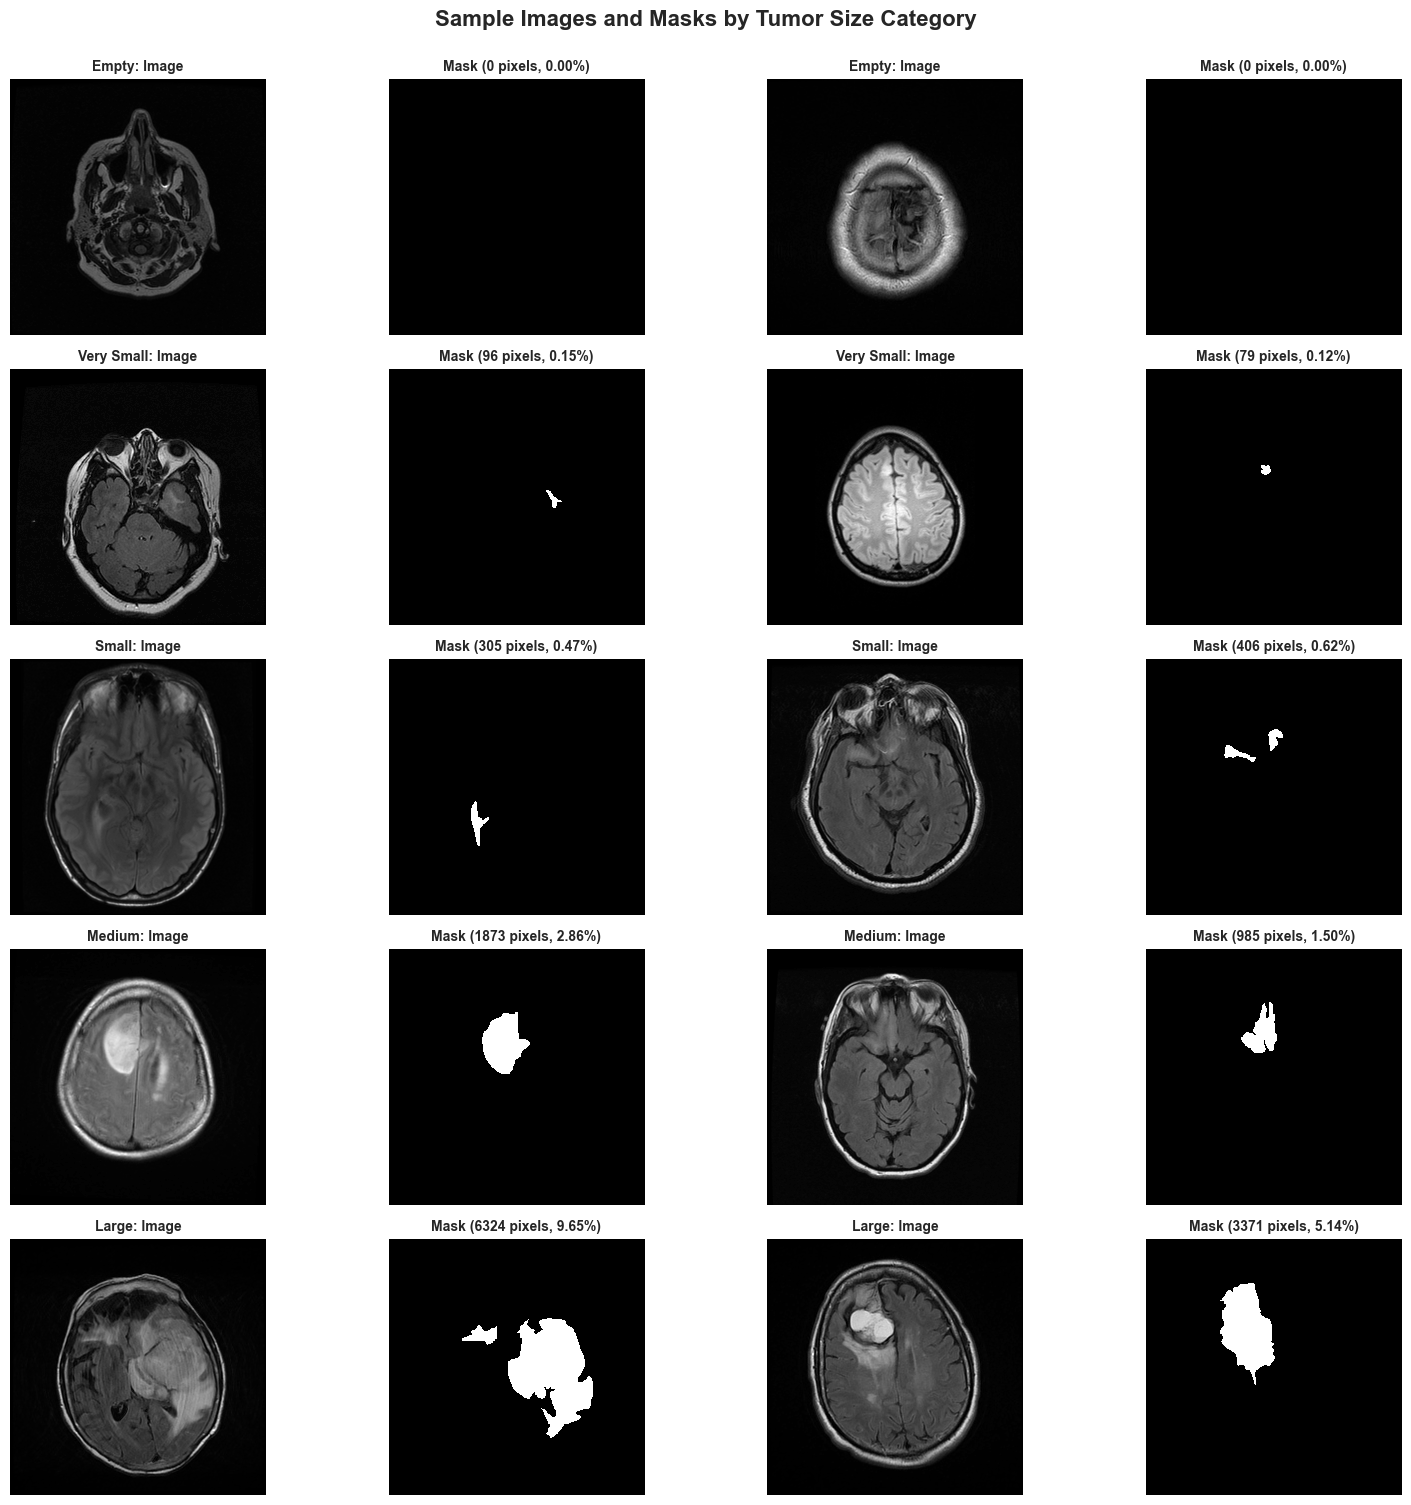

In [11]:
# Visualize samples from each category
categories = ['Empty', 'Very Small', 'Small', 'Medium', 'Large']
samples_per_category = 2

fig, axes = plt.subplots(len(categories), samples_per_category * 2, figsize=(16, len(categories) * 3))

for i, category in enumerate(categories):
    # Get samples from this category
    category_samples = df_masks[df_masks['category'] == category].sample(min(samples_per_category, len(df_masks[df_masks['category'] == category])))
    
    for j, (_, row) in enumerate(category_samples.iterrows()):
        if j >= samples_per_category:
            break
        
        # Load image and mask
        mask_path = Path(row['mask_path'])
        image_path = mask_path.parent / mask_path.name.replace('_mask', '')
        
        image = np.array(Image.open(image_path))
        mask = np.array(Image.open(mask_path))
        
        # Display image (FLAIR channel)
        ax_img = axes[i, j*2]
        ax_img.imshow(image[:, :, 1] if len(image.shape) == 3 else image, cmap='gray')
        ax_img.set_title(f'{category}: Image', fontsize=10, fontweight='bold')
        ax_img.axis('off')
        
        # Display mask
        ax_mask = axes[i, j*2 + 1]
        ax_mask.imshow(mask, cmap='gray')
        ax_mask.set_title(f'Mask ({row["tumor_pixels"]:.0f} pixels, {row["tumor_percentage"]:.2f}%)', 
                         fontsize=10, fontweight='bold')
        ax_mask.axis('off')

plt.suptitle('Sample Images and Masks by Tumor Size Category', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('sample_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Export Analysis Results

In [12]:
# Save detailed analysis to CSV
df_masks.to_csv('mask_analysis.csv', index=False)
patient_tumor_stats.to_csv('patient_tumor_stats.csv', index=False)

print("✓ Analysis results saved:")
print("  - mask_analysis.csv")
print("  - patient_tumor_stats.csv")

# Create summary report
summary = {
    'Total Patients': len(patient_slice_counts),
    'Total Slices': len(df_masks),
    'Empty Masks': empty_masks,
    'Non-Empty Masks': non_empty_masks,
    'Empty Mask Percentage': f"{empty_masks/len(df_masks)*100:.1f}%",
    'Pixel Imbalance Ratio': f"{non_tumor_pixels_all/tumor_pixels_all:.1f}:1",
    'Mean Tumor Pixels (Non-Empty)': f"{non_empty_df['tumor_pixels'].mean():.0f}",
    'Mean Tumor Percentage (Non-Empty)': f"{non_empty_df['tumor_percentage'].mean():.2f}%"
}

summary_df = pd.DataFrame([summary]).T
summary_df.columns = ['Value']
summary_df.to_csv('dataset_summary.csv')

print("  - dataset_summary.csv")
print("\n" + "="*70)
print("DATASET ANALYSIS SUMMARY")
print("="*70)
print(summary_df.to_string())
print("="*70)

✓ Analysis results saved:
  - mask_analysis.csv
  - patient_tumor_stats.csv
  - dataset_summary.csv

DATASET ANALYSIS SUMMARY
                                    Value
Total Patients                        110
Total Slices                         3929
Empty Masks                          2556
Non-Empty Masks                      1373
Empty Mask Percentage               65.1%
Pixel Imbalance Ratio              96.1:1
Mean Tumor Pixels (Non-Empty)        1931
Mean Tumor Percentage (Non-Empty)   2.95%


## 11. Recommendations for Training

In [13]:
print("\n" + "="*70)
print("RECOMMENDATIONS FOR MODEL TRAINING")
print("="*70)

empty_ratio = empty_masks / len(df_masks)
imbalance_ratio = non_tumor_pixels_all / tumor_pixels_all

print("\n1. CLASS IMBALANCE HANDLING:")
if empty_ratio > 0.3:
    print(f"   ⚠️  High proportion of empty masks ({empty_ratio*100:.1f}%)")
    print("   → Recommendation: Use WeightedRandomSampler with reduced weight for empty slices")
    print(f"   → Suggested weights: Empty=0.3-0.5, Small tumors=1.2-1.5, Others=1.0")
else:
    print(f"   ✓ Moderate proportion of empty masks ({empty_ratio*100:.1f}%)")
    print("   → Standard sampling should work fine")

print("\n2. LOSS FUNCTION:")
if imbalance_ratio > 100:
    print(f"   ⚠️  Severe pixel-level imbalance ({imbalance_ratio:.0f}:1)")
    print("   → Recommendation: Use Dice + Focal Loss combination")
    print("   → Suggested: 60-70% Dice + 30-40% Focal Loss")
else:
    print(f"   ✓ Manageable pixel-level imbalance ({imbalance_ratio:.0f}:1)")
    print("   → Dice Loss should be sufficient")

print("\n3. DATA AUGMENTATION:")
mean_tumor_pct = non_empty_df['tumor_percentage'].mean()
if mean_tumor_pct < 5:
    print(f"   ⚠️  Small average tumor size ({mean_tumor_pct:.2f}% of image)")
    print("   → Recommendation: Use careful augmentation to preserve small features")
    print("   → Avoid aggressive elastic transforms that might distort small tumors")
else:
    print(f"   ✓ Reasonable tumor sizes ({mean_tumor_pct:.2f}% of image)")
    print("   → Standard augmentation pipeline should work well")

print("\n4. EVALUATION METRICS:")
print("   → Primary: Dice Score (handles class imbalance)")
print("   → Secondary: IoU, Precision, Recall")
print("   → Monitor: False Negative Rate (important for medical imaging)")

print("\n5. TRAINING STRATEGY:")
print("   → Use patient-level splitting (avoid data leakage)")
print("   → Train/Val/Test split: 70%/15%/15% or 60%/20%/20%")
print("   → Consider cross-validation for robust evaluation")

print("="*70)


RECOMMENDATIONS FOR MODEL TRAINING

1. CLASS IMBALANCE HANDLING:
   ⚠️  High proportion of empty masks (65.1%)
   → Recommendation: Use WeightedRandomSampler with reduced weight for empty slices
   → Suggested weights: Empty=0.3-0.5, Small tumors=1.2-1.5, Others=1.0

2. LOSS FUNCTION:
   ✓ Manageable pixel-level imbalance (96:1)
   → Dice Loss should be sufficient

3. DATA AUGMENTATION:
   ⚠️  Small average tumor size (2.95% of image)
   → Recommendation: Use careful augmentation to preserve small features
   → Avoid aggressive elastic transforms that might distort small tumors

4. EVALUATION METRICS:
   → Primary: Dice Score (handles class imbalance)
   → Secondary: IoU, Precision, Recall
   → Monitor: False Negative Rate (important for medical imaging)

5. TRAINING STRATEGY:
   → Use patient-level splitting (avoid data leakage)
   → Train/Val/Test split: 70%/15%/15% or 60%/20%/20%
   → Consider cross-validation for robust evaluation


## Summary

This notebook provides a comprehensive analysis of the LGG brain tumor dataset, including:

✓ **Patient-level statistics**: Number of slices per patient, distribution patterns

✓ **Class imbalance**: Proportion of empty vs tumor-containing masks

✓ **Tumor size distribution**: Categorization and visualization of tumor sizes

✓ **Pixel-level analysis**: Detailed statistics on tumor pixel counts and percentages

✓ **Training recommendations**: Specific suggestions for handling imbalance and optimizing model performance

The analysis results are saved as CSV files for future reference and can be used to inform training strategies for the brain tumor segmentation model.